# Get Information about BPMAI dataset from model files


Get creation date and print earlist and latest date


In [2]:
import os
import datetime
import json

def get_bpmai_date_range():

    dataset_path = '../data/bpmnmodelset/bpmai/models'
    meta_file_ending = '.meta.json'

    files = os.listdir(dataset_path)

    earliest_model_date = datetime.datetime.max
    latest_model_date = datetime.datetime.min

    for file in files:
        if not file.endswith(meta_file_ending):
            continue

        meta_data_file = json.load(open(os.path.join(dataset_path, file), 'r'))

        model_date = datetime.datetime.fromisoformat(meta_data_file['model']['modelDate'])

        if model_date < earliest_model_date:
            earliest_model_date = model_date
        if model_date > latest_model_date:
            latest_model_date = model_date

    print("Earliest model date: ", earliest_model_date.isoformat())
    print("Last model date: ", latest_model_date.isoformat())

get_bpmai_date_range()

Earliest model date:  2009-09-02T00:00:00
Last model date:  2012-08-30T00:00:00


In [3]:
def _extract_model_metadata(
        metadata_json) -> tuple[str, str, str]:
    id = metadata_json['model']['modelId']
    name = metadata_json['model']['modelName']
    language = metadata_json['model']['naturalLanguage']

    return id, name, language


def _load_model_text(fp: str) -> str:
    with open(fp, 'r') as f:
        model_text = f.read()
    return model_text


 Get language distribution


In [4]:
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType


bpmn_dataset = load_dataset(path='../data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.BPMAI)




In [5]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language
extract_dataset_languages(bpmn_dataset, override=False)
language_dict = get_models_by_language(bpmn_dataset, print_counts=True)



Language Extraction Progress: 0it [00:00, ?it/s]

Language Distribution Across Models:
Language: de, Count: 5212
Language: en, Count: 9956
Language: cs, Count: 91
Language: hu, Count: 643
Language: ro, Count: 15
Language: fr, Count: 255
Language: sk, Count: 66
Language: hr, Count: 450
Language: it, Count: 280
Language: undetermined language, Count: 748
Language: sv, Count: 212
Language: pl, Count: 77
Language: no, Count: 72
Language: ru, Count: 93
Language: nl, Count: 87
Language: es, Count: 316
Language: pt, Count: 85
Language: id, Count: 19
Language: el, Count: 17
Language: so, Count: 10
Language: da, Count: 21
Language: zh-cn, Count: 15
Language: sw, Count: 7
Language: tl, Count: 29
Language: af, Count: 9
Language: vi, Count: 5
Language: fi, Count: 17
Language: sq, Count: 4
Language: bg, Count: 1


In [6]:
len(language_dict.values())

29

In [7]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models, _combine_name_and_count_dicts

extract_names_from_models(bpmn_dataset, use_types=True, include_texts=False, include_documentation=False)
extract_names_from_models(bpmn_dataset, use_types=False, include_texts=False, include_documentation=False)

Printing representations with and without types, and for Hash and TF-IDF duplicate detection.

In [8]:
import json

from mcp4cm.util.text_util import join_texts

from collections import Counter

for model in bpmn_dataset:
    if "1230190255" in model.file_path:
        print("--- MODEL INFORMATION ---")
        print(model.name)
        print(model.file_path)
        print(model.names)
        print(model.names_with_types)
        print(model.element_counts)

        print("--- FOR HASHING ---")

        combined_dict = _combine_name_and_count_dicts(model.names_with_types, model.element_counts)
        print(json.dumps(model.names, sort_keys=True))
        print(json.dumps(combined_dict, sort_keys=True))

        print("--- FOR TF-IDF ---")
        names_joined = join_texts(model.names_with_types, delim=' ', empty_name=None)
        types_elements = list(Counter(model.element_counts).elements())
        types_joined = " ".join(types_elements)
        print(names_joined)
        print(types_joined)
        tf_idf_input = " ".join([names_joined, types_joined])
        print(tf_idf_input)

        break
    else:
        continue


--- MODEL INFORMATION ---
E-mail
../data/bpmnmodelset\bpmai/models\1230190255.json
['Account Verified', 'Email Received', 'User  Verify  Account']
{'BPMNDiagram': [], 'SequenceFlow': [], 'EndNoneEvent': ['Account Verified'], 'Task': ['User  Verify  Account'], 'StartNoneEvent': ['Email Received']}
{'BPMNDiagram': 1, 'SequenceFlow': 2, 'EndNoneEvent': 1, 'Task': 1, 'StartNoneEvent': 1}
--- FOR HASHING ---
["Account Verified", "Email Received", "User  Verify  Account"]
{"BPMNDiagram": {"count": 1, "names": []}, "EndNoneEvent": {"count": 1, "names": ["Account Verified"]}, "SequenceFlow": {"count": 2, "names": []}, "StartNoneEvent": {"count": 1, "names": ["Email Received"]}, "Task": {"count": 1, "names": ["User  Verify  Account"]}}
--- FOR TF-IDF ---
Account Verified User  Verify  Account Email Received
BPMNDiagram SequenceFlow SequenceFlow EndNoneEvent Task StartNoneEvent
Account Verified User  Verify  Account Email Received BPMNDiagram SequenceFlow SequenceFlow EndNoneEvent Task StartNone

# Analyzing texts

In [9]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv



sam_path = '../data/bpmnmodelset/processed/sap_sam_2022/names_only.csv'
bpmai_path = '../data/bpmnmodelset/processed/bpmai/names_only.csv'



In [10]:
english_bpmai = load_processed_dataset_from_csv('English_BPMAI', bpmai_path)

names
a       8413
b       8291
c       8074
d       7803
e       7458
f       7144
g       6766
h       6381
i       6071
j       5787
k       5514
l       5191
m       4921
n       4647
o       4355
p       4135
q       3925
r       3735
s       3497
t       3323
u       3129
v       2926
w       2770
x       2611
no      2554
y       2475
z       2318
yes     2214
aa      2193
ab      2076
ja      2023
ac      1952
ad      1863
ae      1749
nein    1711
af      1652
ne      1612
da      1605
ag      1575
ah      1498
ai      1407
aj      1334
ak      1275
al      1209
am      1152
an      1095
ao      1049
ap       991
aq       933
ar       881
Name: count, dtype: int64

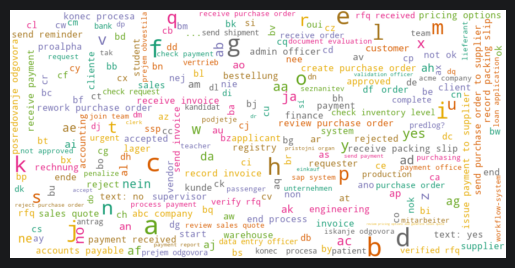

In [11]:
from thesis_and_replication_studies.analysis_and_extraction import get_counts, create_wordcloud

counts = get_counts(english_bpmai, key = 'names', casefold=True, exclude_empty=True)

create_wordcloud(counts)
counts.head(50)

In [12]:
counts_with_empty = get_counts(english_bpmai, key='names', casefold=True, exclude_empty=False)

total = sum(counts_with_empty)
unnamed = counts_with_empty['unnamed']
print("'unnamed' tokens after text extraction:", unnamed)
print("Total number of names (excluding 'unnamed') in dataset:", total - unnamed)

'unnamed' tokens after text extraction: 71298
Total number of names (excluding 'unnamed') in dataset: 401019


In [13]:
from mcp4cm.bpmn.filter_functions import filter_models_by_median_name_length

filter_models_by_median_name_length(english_bpmai, inplace=True)

C:\Entwicklung\envs\py3_13_BA_EAKG\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Entwicklung\envs\py3_13_BA_EAKG\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Filtered out models with a median name length smaller than 3: 9110


Dataset(name=English_BPMAI, models=9702)

In [14]:
from mcp4cm.bpmn.language_detection import filter_models_by_language

english_bpmai = filter_models_by_language(english_bpmai, language='en', key='names', empty_name='unnamed')

names
yes                                2180
no                                 2123
customer                            792
ok                                  355
client                              292
sales                               252
end                                 240
warehouse                           233
supplier                            225
rejected                            225
rfq                                 219
approved                            218
not ok                              209
invoice                             192
ssp                                 186
finance                             178
supervisor                          178
send invoice                        174
review purchase order               154
payment                             153
student                             149
receive invoice                     144
engineering                         142
start                               131
sales quote                       

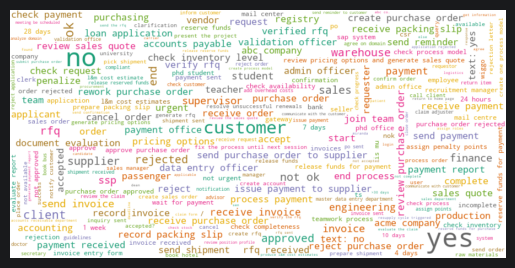

In [15]:
from thesis_and_replication_studies.analysis_and_extraction import get_counts, create_wordcloud

counts = get_counts(english_bpmai, key = 'names', casefold=True, exclude_empty=True)

create_wordcloud(counts)
counts.head(50)

In [16]:
counts.head(50)

names
yes                                2180
no                                 2123
customer                            792
ok                                  355
client                              292
sales                               252
end                                 240
warehouse                           233
supplier                            225
rejected                            225
rfq                                 219
approved                            218
not ok                              209
invoice                             192
ssp                                 186
finance                             178
supervisor                          178
send invoice                        174
review purchase order               154
payment                             153
student                             149
receive invoice                     144
engineering                         142
start                               131
sales quote                       